# 02 · 실제 모델 입력 데이터셋 EDA

전처리된 파일 전체와 모델이 실제로 사용할 수 있는 윈도우는 다릅니다. 이 노트북은 학습·검증·개발 평가 분할과 24시간 입력의 유효 표본을 확인합니다. 기상과 발전량의 관계는 관측상 연관이며 인과 효과나 개별 터빈 파워 커브가 아닙니다.

In [1]:
from pathlib import Path
import os, sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/base_config.yaml").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
runtime = ROOT / ".experiment_archive/python_runtime"
if runtime.exists(): sys.path.insert(0, str(runtime))
from IPython.display import display
from src.workflows import research as wf
%matplotlib inline

In [2]:
wf.split_quality()

,split,start,end,rows,generation_missing,zero_count,zero_pct,incomplete_weather_rows
0,train,2023-01-01 01:00:00,2024-06-30 23:00:00,13127,0,2391,18.214367,10
1,validation,2024-07-01 00:00:00,2024-12-31 23:00:00,4416,0,982,22.237319,51
2,test,2025-01-01 00:00:00,2025-12-31 23:00:00,8760,0,1426,16.278539,0


## 1. 시계열·분포·영발전과 관측소 풍속

바람 그림은 보간하지 않은 관측 기상만 사용합니다. 그림을 보고 2025년을 다시 튜닝하는 절차는 포함하지 않습니다.

C:\Users\Admin\miniconda3\envs\wind_power\Lib\site-packages\IPython\core\events.py:101: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  func(*args, **kwargs)
C:\Users\Admin\miniconda3\envs\wind_power\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.canvas.print_figure(bytes_io, **kw)


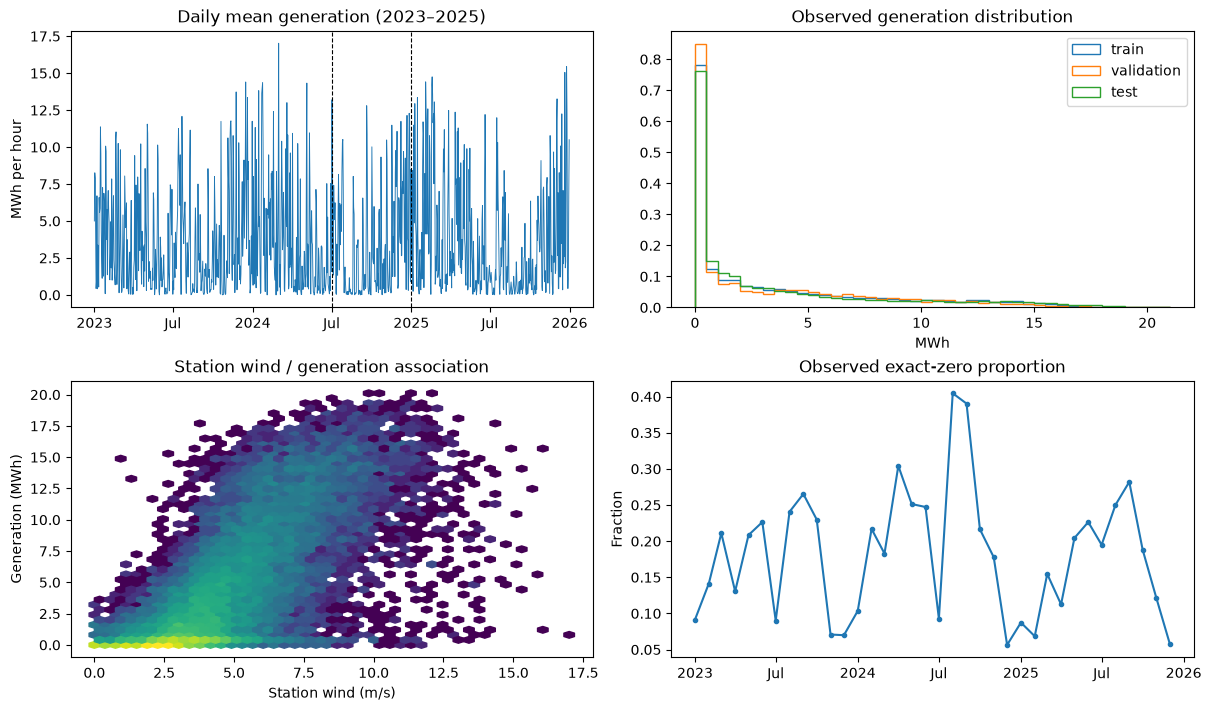

In [3]:
wf.plot_dataset();

## 2. 공통 평가 표본

발행 시각 t의 입력은 [t−23h, t], 타깃은 t+h입니다. 배열의 exclusive index i는 입력 [i−24:i], 타깃 i+h−1에 대응합니다. 결측이 있으면 행을 삭제해 시간을 당기지 않고 해당 윈도우를 제외합니다. 분할 경계마다 윈도우를 새로 시작하므로 검증·평가의 첫 24시간을 과거 구간에서 보충하지 않습니다. 모든 모델을 같은 시각에 비교하기 위해 비기상 모델에도 이 공통 표본 규칙을 적용합니다.

In [4]:
wf.window_counts()

,split,horizon_hours,valid_windows,candidate_windows,excluded_windows
0,train,1,13047,13103,56
1,train,3,13045,13101,56
2,train,6,13042,13098,56
3,train,9,13039,13095,56
4,train,12,13036,13092,56
5,train,24,13024,13080,56
6,validation,1,4249,4392,143
7,validation,3,4247,4390,143
8,validation,6,4244,4387,143
9,validation,9,4241,4384,143


## 3. 실제 한 개 입력과 타깃

아래 발전량 입력은 용량으로 나누고 기상 6채널은 학습 구간의 평균·표준편차로 변환했습니다. EMFN Dataset은 발전량을 MWh로 반환한 뒤 `EMFN.forward()`에서 /21을 수행하고, 일반 신경망 Dataset은 /21을 미리 수행합니다. 같은 물리 단위를 두 번 나누지 않습니다. 24h LightGBM은 기존 규약대로 MWh 발전량을 사용합니다.

In [5]:
X, target = wf.input_example(split="validation", horizon=6)
display(X)
display(target)

,generation_div_21,aws_wind_speed,aws_wind_dir_sin,aws_wind_dir_cos,aws_temperature,aws_humidity,aws_local_pressure
datetime,,,,,,,
2024-07-01 00:00:00,0.018526,-0.331951,-1.658140,-1.045917,1.080244,1.182864,-1.519102
2024-07-01 01:00:00,0.019684,-0.331951,-1.114954,-1.289564,1.067857,1.182864,-1.534962
2024-07-01 02:00:00,0.018526,-0.787200,-0.993537,-1.319775,1.080244,1.188452,-1.566683
2024-07-01 03:00:00,0.011579,-0.621655,-1.639742,-1.057880,1.067857,1.182864,-1.550822
2024-07-01 04:00:00,0.000000,-1.159676,-0.934753,-1.331804,1.030695,1.177275,-1.598403
2024-07-01 05:00:00,0.000000,-0.787200,-0.937706,-1.331239,1.030695,1.182864,-1.598403
2024-07-01 06:00:00,0.008105,-0.580269,-0.616168,-1.369547,0.981147,1.182864,-1.566683
2024-07-01 07:00:00,0.004632,-0.994131,-1.738098,-0.989754,1.055470,1.182864,-1.534962
2024-07-01 08:00:00,0.000000,-1.449379,-1.837077,-0.909241,1.080244,1.182864,-1.534962


,issue_time,target_time,horizon_hours,generation_mwh
0,2024-07-01 23:00:00,2024-07-02 05:00:00,6,12.18221


## 4. 코드 추적 경로

`prepare_splits()` → train-only weather scaler → `valid_window_indices()` → `WindTimeSeriesDataset` / `EMFNMultiChannelDataset` / `flattened_windows()`. 입력 특징은 명시적인 7채널이며 `is_zero`, 원본 단위, 타깃 시각 풍속 등 정답·감사 열은 입력에 들어가지 않습니다.

**다음:** [03 · 베이스라인 학습과 평가](03_baseline_training_and_metrics.ipynb).